<a href="https://colab.research.google.com/github/wmaher1/Data-Science-2/blob/main/project_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# X-ray 8 Classification

## Setup

In [ ]:
import tensorflow as tf

tf.test.gpu_device_name()

'/device:GPU:0'

In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, applications
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


### This is just actually downloading the data, I already have downloaded in my colab notebook

In [ ]:
# import os, subprocess
# from concurrent.futures import ThreadPoolExecutor
# import tarfile

# os.makedirs('/content/downloads', exist_ok=True)
# os.chdir('/content/downloads')
# links = ['https://nihcc.box.com/shared/static/vfk49d74nhbxq3nqjg0900w5nvkorp5c.gz']
# def download_file(url, idx):
#     fn = f'images_{idx+1:02d}.tar.gz'
#     print("Downloading", fn)
#     subprocess.run(f"wget -c -q --show-progress --tries=3 --waitretry=5 {url} -O {fn}", shell=True, check=True)
#     return fn

# with ThreadPoolExecutor(max_workers=2) as ex:
#     _ = [ex.submit(download_file, url, i) for i, url in enumerate(links)]
# print("Download complete")

# os.makedirs('/content/downloads/images', exist_ok=True)
# for f in os.listdir('/content/downloads'):
#     if f.endswith('.tar.gz'):
#         print("Extracting", f)
#         with tarfile.open(f"/content/downloads/{f}", 'r:gz') as tar:
#             tar.extractall(path='/content/downloads/images')
# print("Extraction complete")

In [ ]:
# Set paths
base_dir = '/content/gdrive/My Drive/Colab Notebooks'
image_dir = os.path.join(base_dir, 'downloads/images')
os.makedirs(image_dir, exist_ok=True)

## Preparing the data

In [ ]:
df = pd.read_csv(os.path.join(base_dir, 'Data_Entry_2017.csv'))

classes = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
           'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation',
           'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']

# encoding
def encode_labels(label_string):
    encoded = np.zeros(len(classes), dtype=np.float32)
    for disease in label_string.split('|'):
        if disease in classes:
            encoded[classes.index(disease)] = 1.0
    return encoded

df['encoded_labels'] = df['Finding Labels'].apply(encode_labels)

### Partitioning

In [ ]:
train_val_files = pd.read_csv(os.path.join(base_dir, 'train_val_list.txt'), header=None, names=['filename'])
test_files = pd.read_csv(os.path.join(base_dir, 'test_list.txt'), header=None, names=['filename'])

train_val_df = df.loc[df['Image Index'].isin(train_val_files['filename'])].copy()
test_df = df.loc[df['Image Index'].isin(test_files['filename'])].copy()

train_df, val_df = train_test_split(train_val_df, test_size=0.2, random_state=42)

In [ ]:
train_df['image_path'] = train_df['Image Index'].apply(lambda x: os.path.join(image_dir, x))
val_df['image_path'] = val_df['Image Index'].apply(lambda x: os.path.join(image_dir, x))
test_df['image_path'] = test_df['Image Index'].apply(lambda x: os.path.join(image_dir, x))

train_df = train_df[train_df['image_path'].apply(lambda x: os.path.exists(x))]
val_df = val_df[val_df['image_path'].apply(lambda x: os.path.exists(x))]

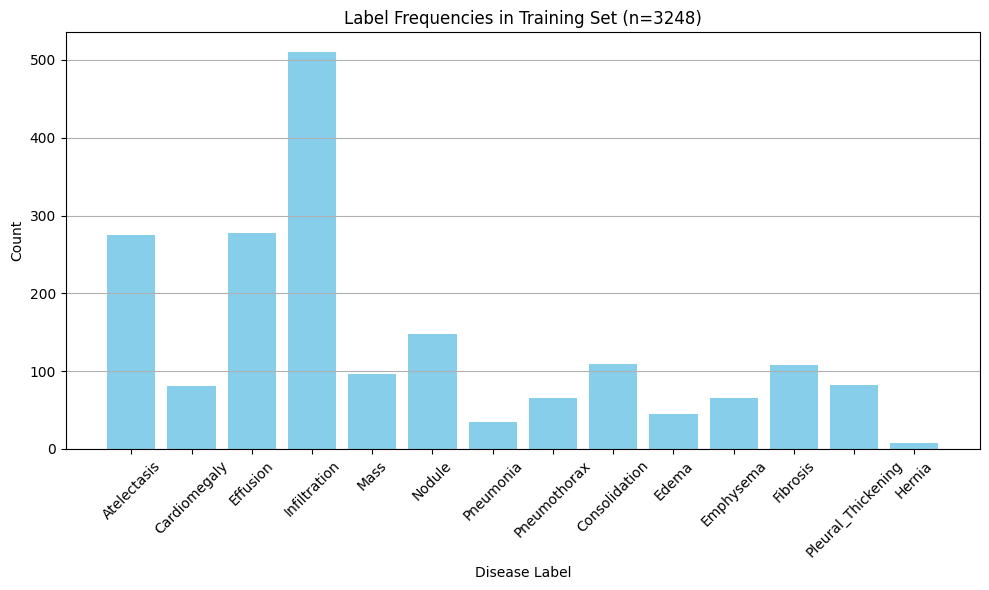

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Stack one-hot encoded labels and sum for each class
label_matrix = np.vstack(train_df['encoded_labels'].values)
frequencies = label_matrix.sum(axis=0)

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.bar(classes, frequencies, color='skyblue')
plt.xticks(rotation=45)
plt.title("Label Frequencies in Training Set (n=3248)")
plt.xlabel("Disease Label")
plt.ylabel("Count")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Data Pipeline

In [ ]:
def load_and_preprocess_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0 # normalizing
    return img, label

def create_dataset(df, batch_size=32, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((df['image_path'], df['encoded_labels'].values.tolist()))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)

    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_df, batch_size=32, shuffle=True)
val_ds = create_dataset(val_df, batch_size=32, shuffle=False)

In [ ]:
len(train_df)
len(val_ds)

25

# DenseNet-121

In [ ]:
base_model = applications.DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(classes), activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)


callbacks = [
    EarlyStopping(monitor="val_auc", patience=5, mode='max'),
    ModelCheckpoint(
        filepath="best_densenet_model.keras",
        monitor="val_auc",
        save_best_only=True,
        mode='max'
    )]

history = model.fit(train_ds, validation_data=val_ds, callbacks=callbacks, epochs=250)

Epoch 1/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 56s 345ms/step - accuracy: 0.1408 - auc: 0.6007 - loss: 0.3058 - val_accuracy: 0.0944 - val_auc: 0.6959 - val_loss: 0.1644
Epoch 2/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.2178 - auc: 0.7406 - loss: 0.1613 - val_accuracy: 0.0957 - val_auc: 0.7065 - val_loss: 0.1609
Epoch 3/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.1811 - auc: 0.7459 - loss: 0.1626 - val_accuracy: 0.1518 - val_auc: 0.7346 - val_loss: 0.1560
Epoch 4/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - accuracy: 0.1968 - auc: 0.7672 - loss: 0.1529 - val_accuracy: 0.1263 - val_auc: 0.7391 - val_loss: 0.1560
Epoch 5/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - accuracy: 0.2103 - auc: 0.7906 - loss: 0.1507 - val_accuracy: 0.2015 - val_auc: 0.7492 - val_loss: 0.1537
Epoch 6/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - accuracy: 0.2302 - auc: 0.7948 - loss: 0.1465 - val_accuracy: 0.2398 - val_auc: 0.7511 - val_loss: 0.1528
Epoch 7/250
102/

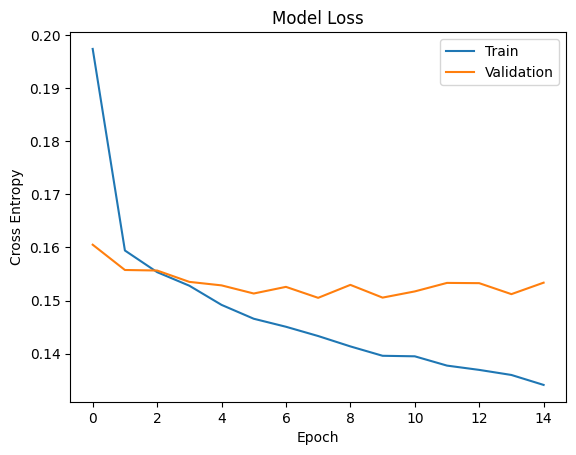

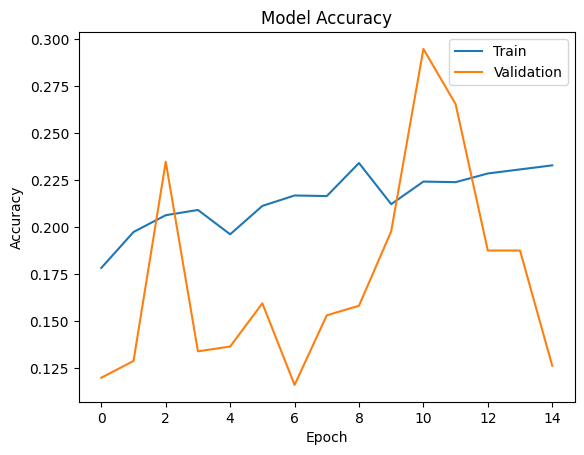

<function matplotlib.pyplot.show(close=None, block=None)>

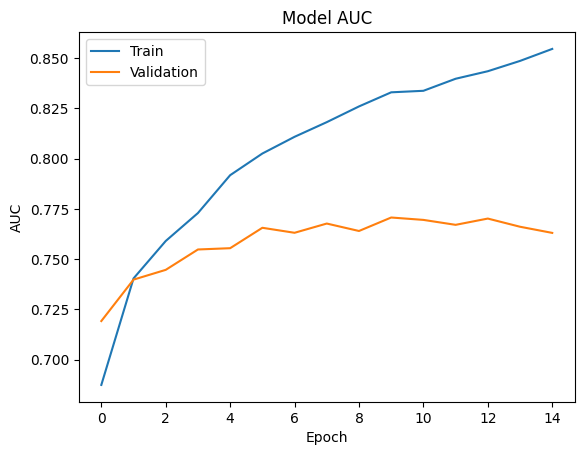

In [ ]:
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy')
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.show()

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.show()

plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.plot(history.history['auc'], label='Train')
plt.plot(history.history['val_auc'], label='Validation')
plt.legend()
plt.show

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model('best_densenet_model.keras', compile=True)

# creating test dataset
test_df['image_exists'] = test_df['image_path'].apply(lambda x: os.path.exists(x))
test_df = test_df[test_df['image_exists']]

test_ds = create_dataset(test_df, batch_size=32, shuffle=False)

results = best_model.evaluate(test_ds)


auc = results[2]
accuracy = results[1]

print(f"Test AUC: {auc}")
print(f"Test Accuracy: {accuracy}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 274ms/step - accuracy: 0.1776 - auc: 0.6885 - loss: 0.3056
Test AUC: 0.7052705883979797
Test Accuracy: 0.19958634674549103


In [ ]:
print(results)

[0.2627154290676117, 0.2202688753604889, 0.7012813687324524]


31/31 ━━━━━━━━━━━━━━━━━━━━ 22s 398ms/step


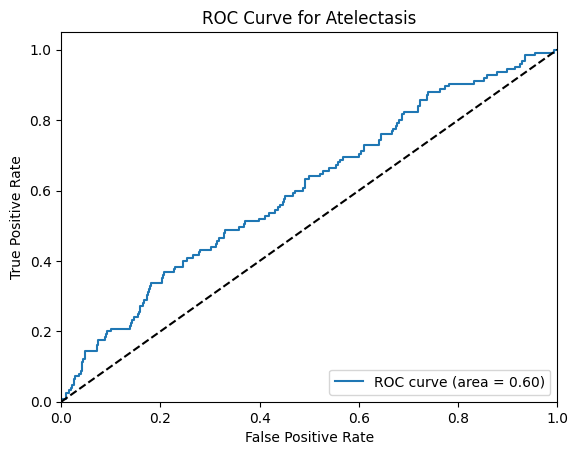

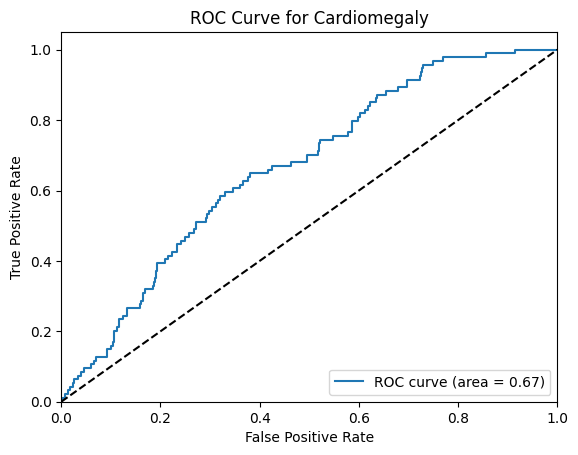

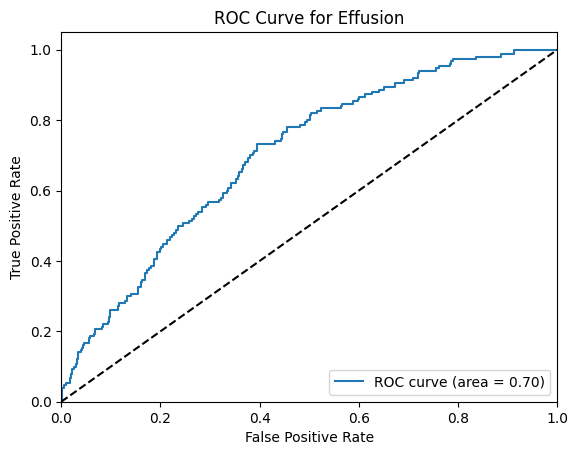

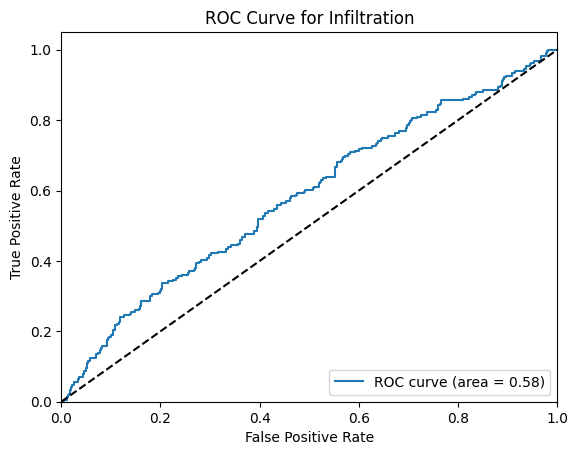

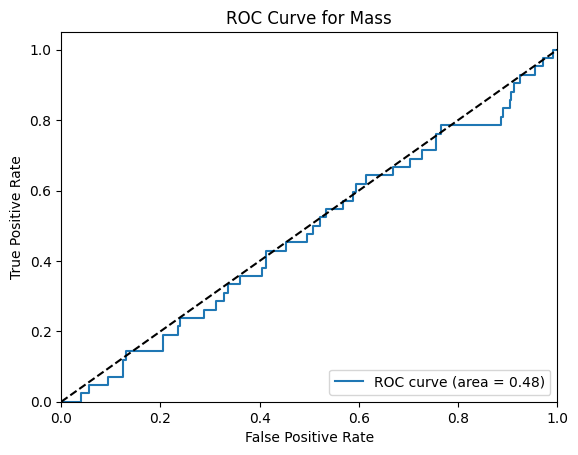

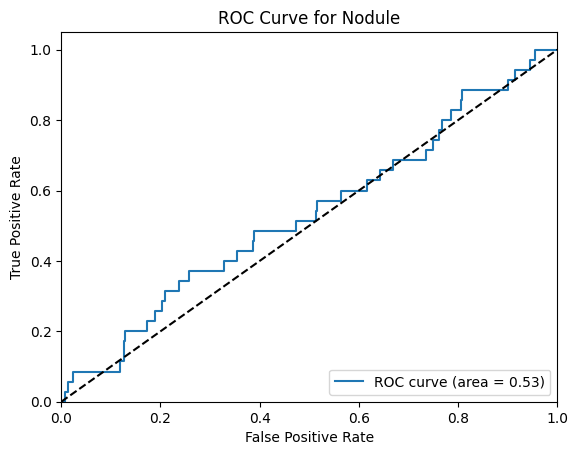

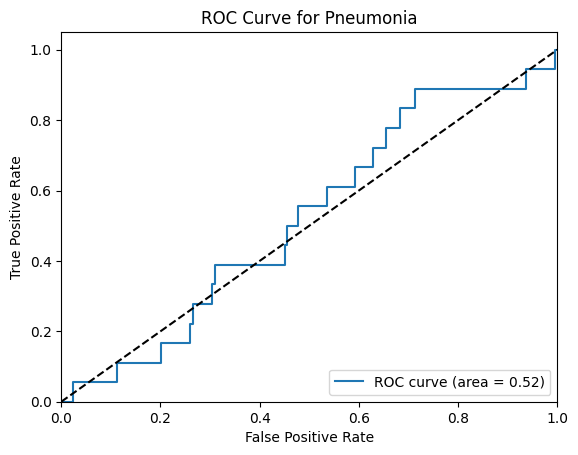

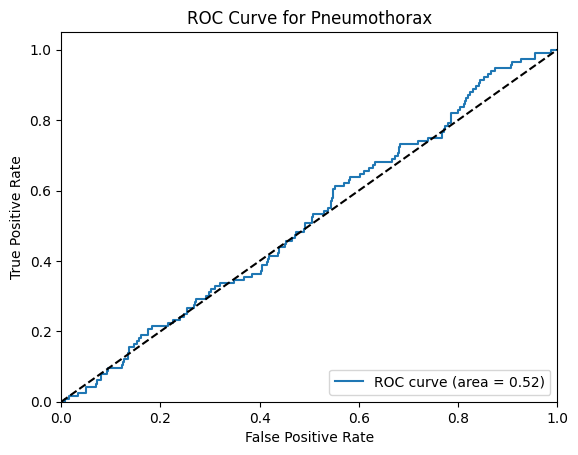

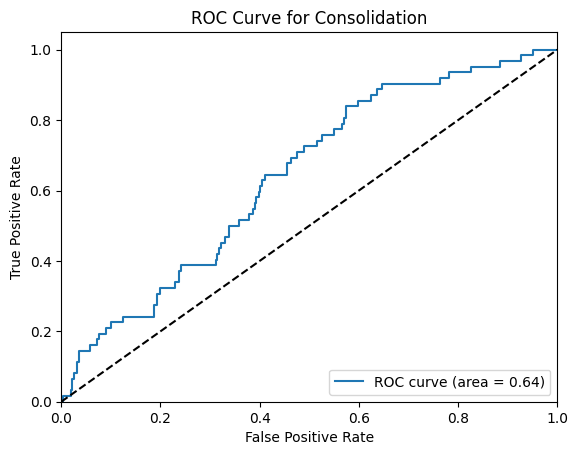

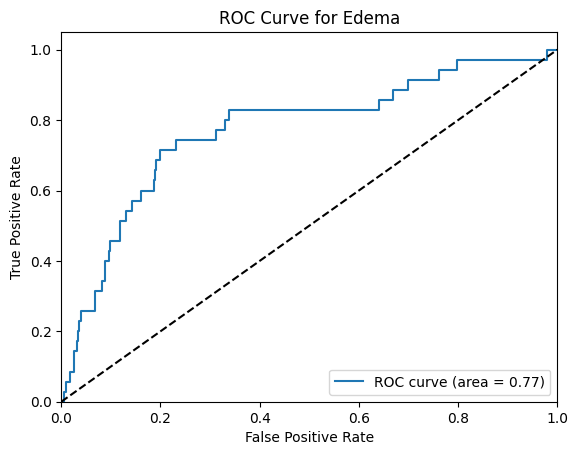

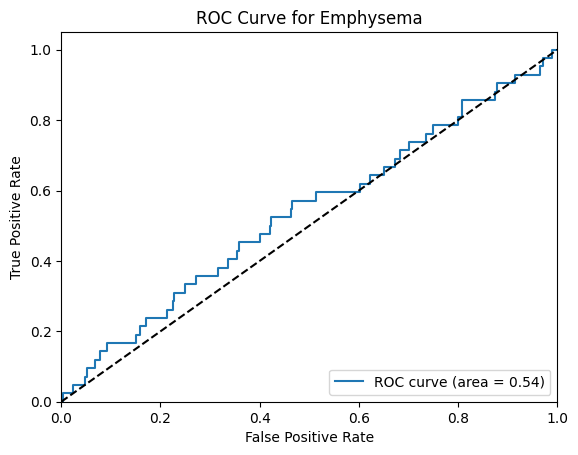

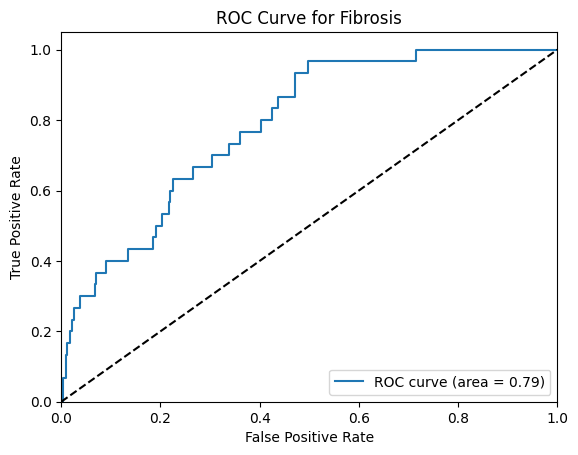

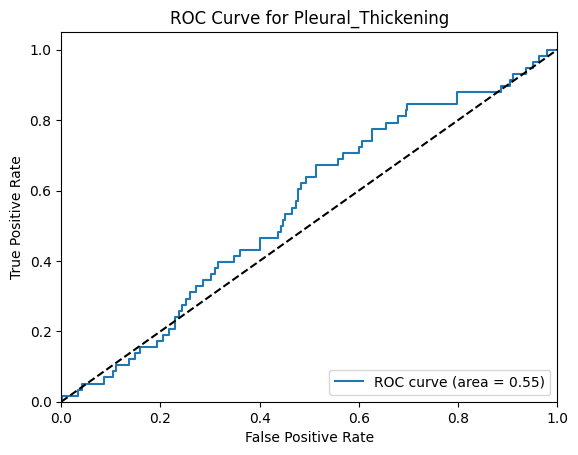

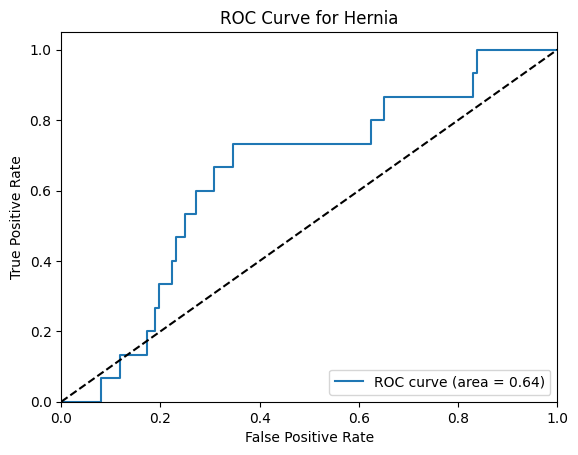

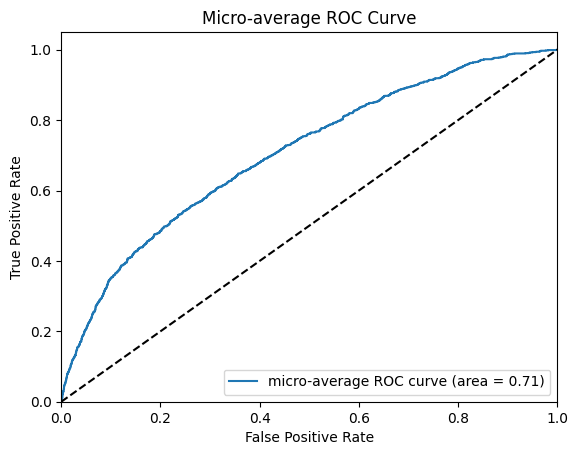

In [ ]:
from sklearn.metrics import roc_curve, auc

y_pred_prob = best_model.predict(test_ds)

y_true = np.array(list(test_df['encoded_labels']))

# roc for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

for i in range(len(classes)):
    plt.figure()
    plt.plot(fpr[i], tpr[i], label='ROC curve (area = %0.2f)' % roc_auc[i])
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {classes[i]}')
    plt.legend(loc="lower right")
    plt.show()

fpr["micro"], tpr["micro"], _ = roc_curve(y_true.ravel(), y_pred_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-average ROC Curve')
plt.legend(loc="lower right")
plt.show()



Processing image 1: /content/gdrive/My Drive/Colab Notebooks/downloads/images/00000003_001.png


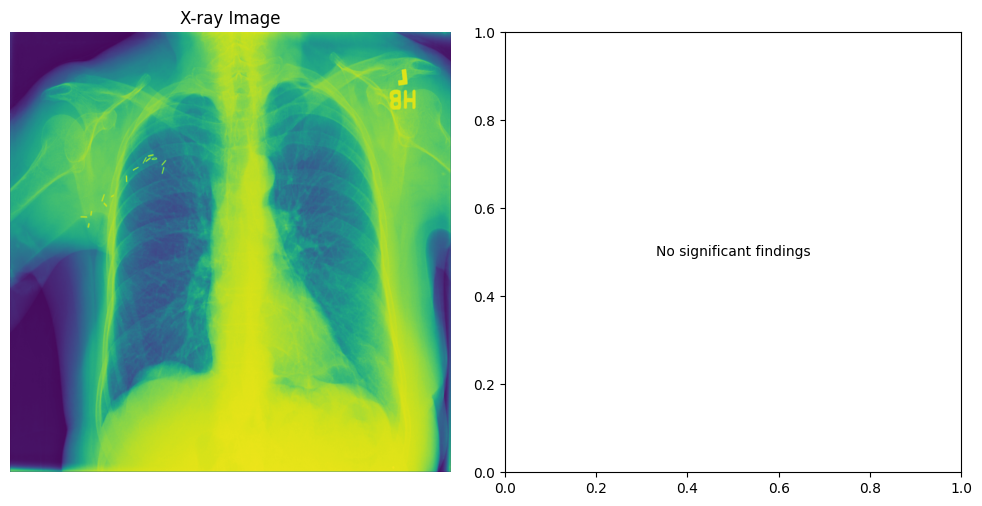

Detailed Predictions:
1. Atelectasis         : 0.050
2. Cardiomegaly        : 0.011
3. Effusion            : 0.043
4. Infiltration        : 0.057
5. Mass                : 0.046
6. Nodule              : 0.037
7. Pneumonia           : 0.003
8. Pneumothorax        : 0.015
9. Consolidation       : 0.007
10. Edema               : 0.000
11. Emphysema           : 0.017
12. Fibrosis            : 0.088
13. Pleural_Thickening  : 0.030
14. Hernia              : 0.001

Processing image 2: /content/gdrive/My Drive/Colab Notebooks/downloads/images/00000003_002.png


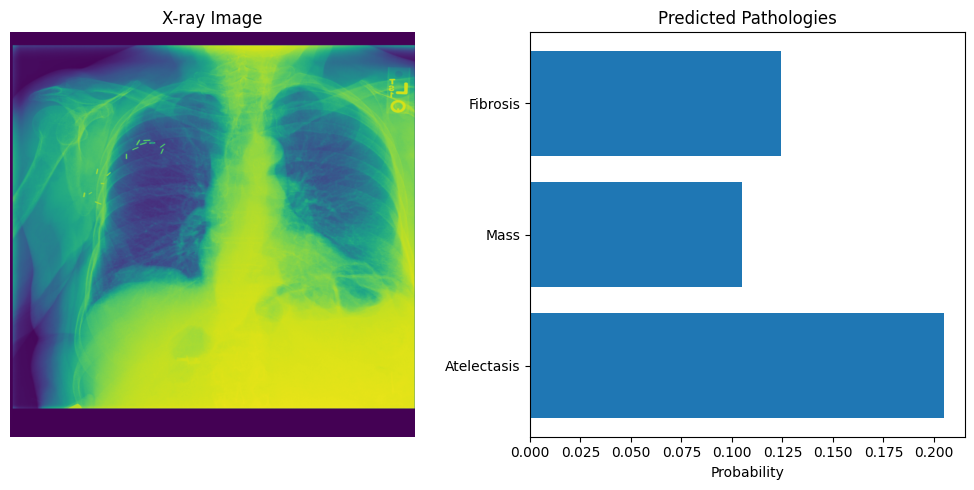

Detailed Predictions:
1. Atelectasis         : 0.205
2. Cardiomegaly        : 0.019
3. Effusion            : 0.068
4. Infiltration        : 0.030
5. Mass                : 0.105
6. Nodule              : 0.008
7. Pneumonia           : 0.013
8. Pneumothorax        : 0.001
9. Consolidation       : 0.003
10. Edema               : 0.002
11. Emphysema           : 0.008
12. Fibrosis            : 0.125
13. Pleural_Thickening  : 0.029
14. Hernia              : 0.000

Processing image 3: /content/gdrive/My Drive/Colab Notebooks/downloads/images/00000003_003.png


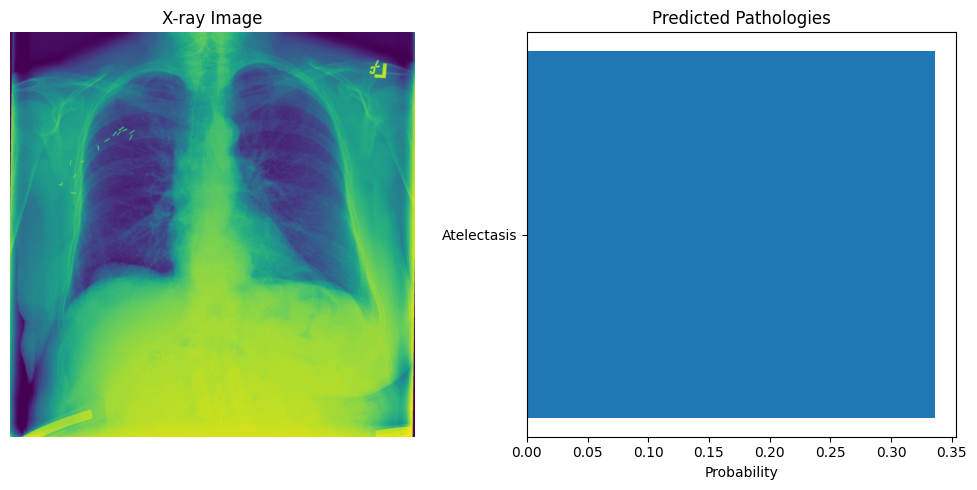

Detailed Predictions:
1. Atelectasis         : 0.336
2. Cardiomegaly        : 0.015
3. Effusion            : 0.030
4. Infiltration        : 0.054
5. Mass                : 0.090
6. Nodule              : 0.030
7. Pneumonia           : 0.004
8. Pneumothorax        : 0.003
9. Consolidation       : 0.003
10. Edema               : 0.000
11. Emphysema           : 0.006
12. Fibrosis            : 0.077
13. Pleural_Thickening  : 0.024
14. Hernia              : 0.000


In [ ]:
# 1. First define the image preprocessing function
def preprocess_image(img_path):
    """Load and preprocess image for DenseNet121"""
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)
    return np.expand_dims(img_array, axis=0)

# 2. Define the visualization function
def show_image_with_predictions(img_path, preds, classes):
    """Display image with predicted probabilities"""
    img = plt.imread(img_path)
    plt.figure(figsize=(10, 5))

    # Show image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title("X-ray Image")

    # Show predictions
    plt.subplot(1, 2, 2)
    # Filter predictions > 10% probability
    significant_preds = [(c, p) for c, p in zip(classes, preds) if p > 0.1]
    if not significant_preds:
        plt.text(0.5, 0.5, "No significant findings",
                ha='center', va='center')
    else:
        # Create bar plot
        plt.barh(
            [c for c, p in significant_preds],
            [p for c, p in significant_preds]
        )
        plt.xlabel('Probability')
        plt.title('Predicted Pathologies')

    plt.tight_layout()
    plt.show()

    # Print numerical values
    print("Detailed Predictions:")
    for i, (class_name, prob) in enumerate(zip(classes, preds)):
        print(f"{i+1}. {class_name:<20}: {prob:.3f}")

# 3. Now process and display images
for i in range(3):  # First 3 test images
    try:
        img_path = test_df['image_path'].iloc[i]
        print(f"\n{'='*50}\nProcessing image {i+1}: {img_path}")

        # Preprocess and predict
        img_array = preprocess_image(img_path)
        preds = model.predict(img_array, verbose=0)[0]

        # Visualize
        show_image_with_predictions(img_path, preds, classes)

    except Exception as e:
        print(f"Error processing {img_path}: {str(e)}")

## Now with specific image that has firbrosis (I specifically looked through the 'Data_Entry_2017.csv')


Processing image: /content/gdrive/My Drive/Colab Notebooks/downloads/images/00000022_001.png


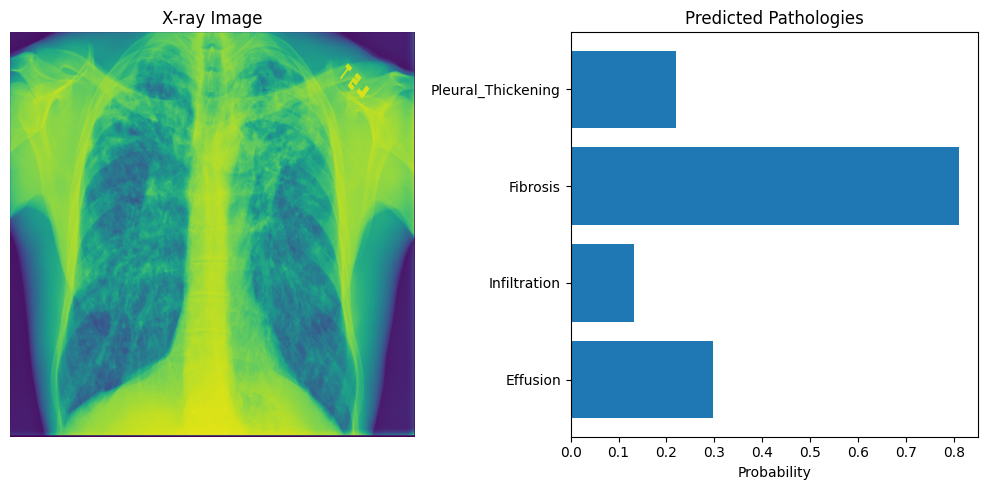

Detailed Predictions:
1. Atelectasis         : 0.032
2. Cardiomegaly        : 0.002
3. Effusion            : 0.297
4. Infiltration        : 0.131
5. Mass                : 0.009
6. Nodule              : 0.092
7. Pneumonia           : 0.013
8. Pneumothorax        : 0.010
9. Consolidation       : 0.039
10. Edema               : 0.000
11. Emphysema           : 0.003
12. Fibrosis            : 0.811
13. Pleural_Thickening  : 0.220
14. Hernia              : 0.000


In [ ]:
# 1. First define the image preprocessing function
def preprocess_image(img_path):
    """Load and preprocess image for DenseNet121"""
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)
    return np.expand_dims(img_array, axis=0)

# 2. Define the visualization function
def show_image_with_predictions(img_path, preds, classes):
    """Display image with predicted probabilities"""
    img = plt.imread(img_path)
    plt.figure(figsize=(10, 5))

    # Show image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title("X-ray Image")

    # Show predictions
    plt.subplot(1, 2, 2)
    # Filter predictions > 10% probability
    significant_preds = [(c, p) for c, p in zip(classes, preds) if p > 0.1]
    if not significant_preds:
        plt.text(0.5, 0.5, "No significant findings",
                ha='center', va='center')
    else:
        # Create bar plot
        plt.barh(
            [c for c, p in significant_preds],
            [p for c, p in significant_preds]
        )
        plt.xlabel('Probability')
        plt.title('Predicted Pathologies')

    plt.tight_layout()
    plt.show()

    # Print numerical values
    print("Detailed Predictions:")
    for i, (class_name, prob) in enumerate(zip(classes, preds)):
        print(f"{i+1}. {class_name:<20}: {prob:.3f}")

# 3. Now process and display the specific image
specific_image = '/content/gdrive/My Drive/Colab Notebooks/downloads/images/00000022_001.png'
try:
    print(f"\n{'='*50}\nProcessing image: {specific_image}")

    # Preprocess and predict
    img_array = preprocess_image(specific_image)
    preds = model.predict(img_array, verbose=0)[0]

    # Visualize
    show_image_with_predictions(specific_image, preds, classes)

except Exception as e:
    print(f"Error processing {specific_image}: {str(e)}")

Model layers:
0: input_layer_9 - Input Layer (shape defined by input)
1: densenet121 - (None, 7, 7, 1024)
2: global_average_pooling2d_4 - Input Layer (shape defined by input)
3: dropout_4 - Input Layer (shape defined by input)
4: dense_4 - Input Layer (shape defined by input)
Image array shape: (1, 224, 224, 3)
Heatmap shape: (7, 7)


<ipython-input-108-476d0a744a54>:77: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


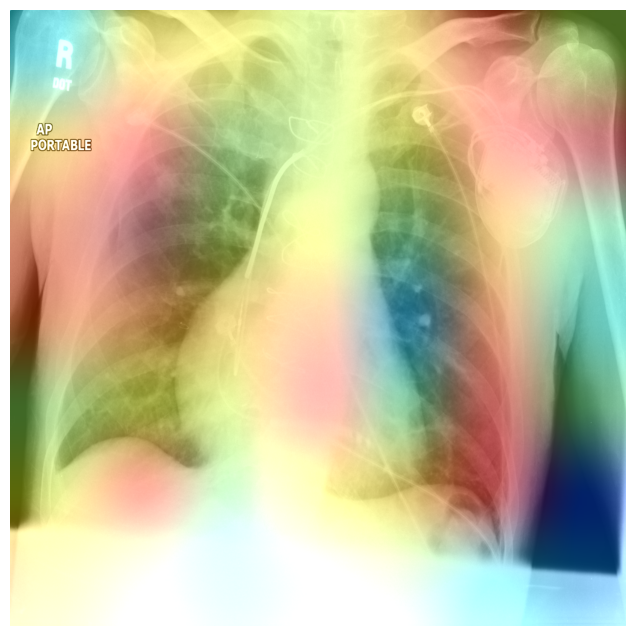

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Model predictions: [[5.8645826e-02 1.2713129e-02 8.8366941e-03 8.9838080e-02 9.8438658e-02
  1.1337582e-01 4.8925555e-03 3.2451337e-03 2.4131697e-02 1.9745179e-04
  1.0671784e-01 1.5435028e-02 4.7663394e-02 8.1398764e-05]]
Predicted class: 5


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

# 1. VERIFY MODEL STRUCTURE
print("Model layers:")
for i, layer in enumerate(best_model.layers):
    try:  # Try to access output_shape, if available
        print(f"{i}: {layer.name} - {layer.output_shape}")
    except AttributeError:  # Handle InputLayer case
        print(f"{i}: {layer.name} - Input Layer (shape defined by input)")

# 2. PROPER IMAGE PREPROCESSING
def get_img_array(img_path, size=(224, 224)):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    array = tf.keras.preprocessing.image.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    array = tf.keras.applications.densenet.preprocess_input(array)
    return array

# 3. MODIFIED GRAD-CAM IMPLEMENTATION
def make_gradcam_heatmap(img_array, model, last_conv_layer_name='conv5_block16_concat'):
    # Create a model that maps the input image to the activations
    # of the last conv layer and the output predictions
    densenet = model.layers[1]  # Get the DenseNet base model

    # Create temporary model that goes from input to conv layer outputs
    conv_layer = densenet.get_layer(last_conv_layer_name)
    conv_model = Model(inputs=densenet.input, outputs=conv_layer.output)

    # Create model that goes from conv outputs to final predictions
    gap_layer = model.layers[2]  # GlobalAveragePooling2D
    dropout_layer = model.layers[3]  # Dropout
    dense_layer = model.layers[4]  # Dense

    # Compute gradients
    with tf.GradientTape() as tape:
        # Get conv outputs
        conv_outputs = conv_model(img_array)
        tape.watch(conv_outputs)

        # Get predictions
        x = gap_layer(conv_outputs)
        x = dropout_layer(x)
        predictions = dense_layer(x)

        # Get the top predicted class
        top_pred_index = tf.argmax(predictions[0])
        top_class_channel = predictions[:, top_pred_index]

    # Compute gradients of the top predicted class with respect to conv outputs
    grads = tape.gradient(top_class_channel, conv_outputs)

    # Pool gradients spatially (average over width and height)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the conv outputs by importance
    conv_outputs = conv_outputs[0]  # Remove batch dimension
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize between 0-1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# 4. VISUALIZATION FUNCTION
def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load original image
    img = tf.keras.preprocessing.image.load_img(img_path)
    img = tf.keras.preprocessing.image.img_to_array(img)

    # Rescale heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)

    # Create colormap
    jet = plt.cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create overlay
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
    superimposed_img = Image.fromarray(superimposed_img)

    # Display
    plt.figure(figsize=(10, 8))
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()

# 5. EXECUTION
try:
    img_path = '/content/gdrive/My Drive/Colab Notebooks/downloads/images/00000013_024.png'

    # Get properly preprocessed image
    img_array = get_img_array(img_path)
    print(f"Image array shape: {img_array.shape}")

    # Generate heatmap - try both common layer names
    try:
        heatmap = make_gradcam_heatmap(img_array, best_model, 'conv5_block16_concat')
    except:
        heatmap = make_gradcam_heatmap(img_array, best_model, 'relu')

    print(f"Heatmap shape: {heatmap.shape}")

    # Display results
    display_gradcam(img_path, heatmap)

    # Show model predictions
    preds = best_model.predict(img_array)
    print(f"Model predictions: {preds}")
    print(f"Predicted class: {tf.argmax(preds[0])}")

except Exception as e:
    print(f"Error: {str(e)}")
    print("\nDebugging information:")
    print("Available layers in DenseNet submodel:")
    densenet = best_model.layers[1]
    for i, layer in enumerate(densenet.layers):
        if len(layer.output.shape) == 4:  # Only show conv layers
            print(f"{i}: {layer.name} - {layer.output.shape}")

# EfficientNetB0

In [ ]:
# Build EfficientNetB0 Model

base_model = applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(classes), activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │        17,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,067,505 (15.52 MB)

 Trainable params: 17,934 (70.05 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Train with Callbacks

callbacks = [
    EarlyStopping(monitor='val_auc', patience=5, mode='max'),
    ModelCheckpoint('efficientnetb0_best.keras', monitor='val_auc',
                    save_best_only=True, mode='max')
]

history = model.fit(train_ds, validation_data=val_ds, epochs=250, callbacks=callbacks)

Epoch 1/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 56s 330ms/step - accuracy: 0.0818 - auc: 0.5860 - loss: 0.2528 - val_accuracy: 0.0957 - val_auc: 0.7044 - val_loss: 0.1613
Epoch 2/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.1189 - auc: 0.7246 - loss: 0.1623 - val_accuracy: 0.0957 - val_auc: 0.7003 - val_loss: 0.1626
Epoch 3/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.1215 - auc: 0.7267 - loss: 0.1574 - val_accuracy: 0.0957 - val_auc: 0.7009 - val_loss: 0.1623
Epoch 4/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.1199 - auc: 0.7273 - loss: 0.1602 - val_accuracy: 0.0957 - val_auc: 0.7013 - val_loss: 0.1632
Epoch 5/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.1126 - auc: 0.7249 - loss: 0.1658 - val_accuracy: 0.0957 - val_auc: 0.6963 - val_loss: 0.1626
Epoch 6/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.1183 - auc: 0.7255 - loss: 0.1629 - val_accuracy: 0.0957 - val_auc: 0.6926 - val_loss: 0.1621


In [ ]:
best_model = load_model('efficientnetb0_best.keras',
                        custom_objects={'AUC': tf.keras.metrics.AUC})

test_df['image_exists'] = test_df['image_path'].apply(os.path.exists)
test_df = test_df[test_df['image_exists']]

test_ds = create_dataset(test_df, batch_size=32, shuffle=False)

results = best_model.evaluate(test_ds)

test_loss = results[0]
test_accuracy = results[1]
test_auc = results[2]

print("\n--- Test Set Evaluation ---")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test AUC      : {test_auc:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 284ms/step - accuracy: 0.1421 - auc: 0.6323 - loss: 0.3226

--- Test Set Evaluation ---
Test Loss     : 0.2755
Test Accuracy : 0.1448
Test AUC      : 0.6606


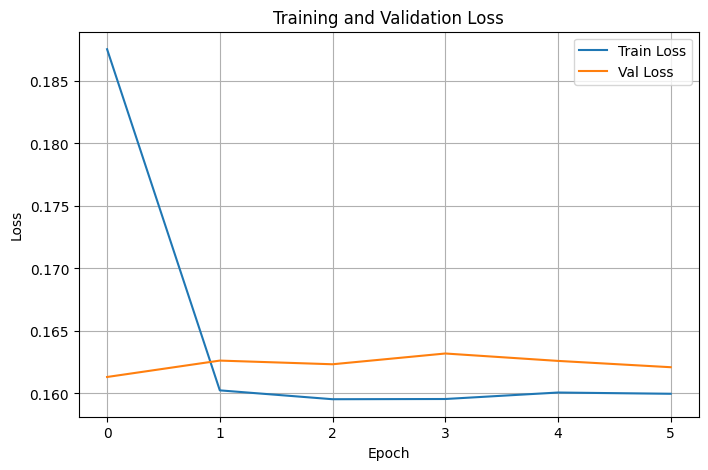

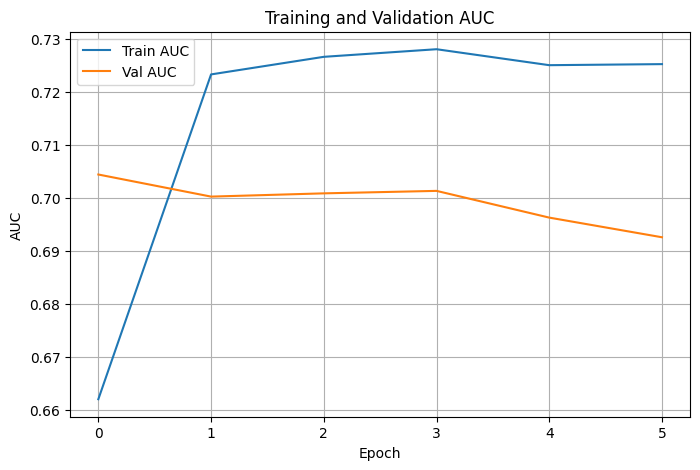

In [ ]:
# Plot Training & Validation Loss and AUC
import matplotlib.pyplot as plt

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# AUC plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Training and Validation AUC')
plt.legend()
plt.grid(True)
plt.show()

# Resnet

In [ ]:
# Build ResNet50 Model
base_model = applications.ResNet50(weights='imagenet', include_top=False,
                                   input_shape=(224, 224, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(classes), activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │        28,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,616,398 (90.09 MB)

 Trainable params: 28,686 (112.05 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Train with Callbacks
callbacks = [
    EarlyStopping(monitor='val_auc', patience=5, mode='max'),
    ModelCheckpoint(
        filepath='best_resnet_model.keras',
        monitor='val_auc', save_best_only=True, mode='max')
]

history = model.fit(train_ds, validation_data=val_ds, epochs=250, callbacks=callbacks)

Epoch 1/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 37s 233ms/step - accuracy: 0.0824 - auc: 0.5906 - loss: 0.2559 - val_accuracy: 0.0957 - val_auc: 0.7012 - val_loss: 0.1622
Epoch 2/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.1574 - auc: 0.7148 - loss: 0.1604 - val_accuracy: 0.0957 - val_auc: 0.6922 - val_loss: 0.1639
Epoch 3/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.1288 - auc: 0.7146 - loss: 0.1619 - val_accuracy: 0.0957 - val_auc: 0.6996 - val_loss: 0.1617
Epoch 4/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.1409 - auc: 0.7113 - loss: 0.1689 - val_accuracy: 0.0957 - val_auc: 0.6954 - val_loss: 0.1630
Epoch 5/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.1266 - auc: 0.7201 - loss: 0.1653 - val_accuracy: 0.0957 - val_auc: 0.6949 - val_loss: 0.1630
Epoch 6/250
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.1356 - auc: 0.7162 - loss: 0.1604 - val_accuracy: 0.0957 - val_auc: 0.7034 - val_loss: 0.1627
Epoch 7/250
102/

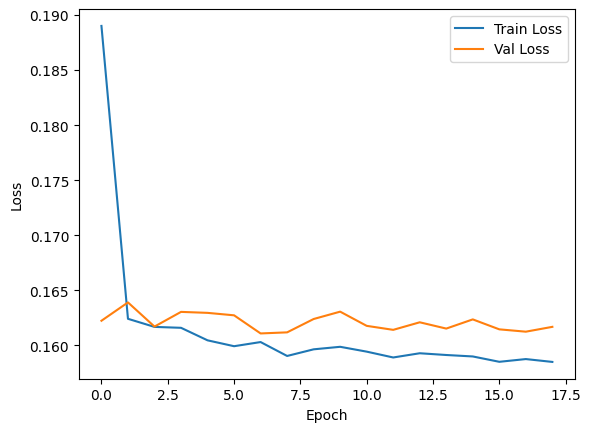

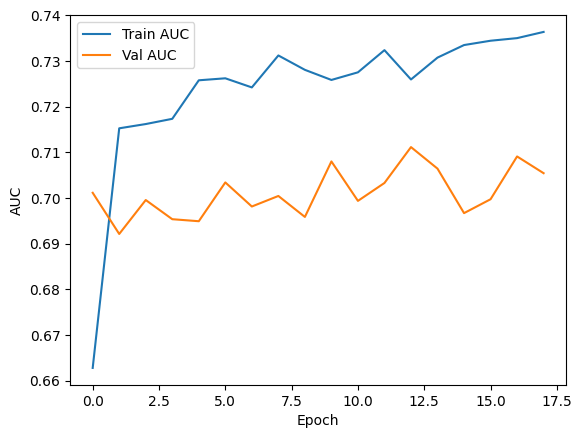

In [ ]:
# Plot Training & Validation Loss and AUC
import matplotlib.pyplot as plt

# Loss curves
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# AUC curves
plt.figure()
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.show()

In [ ]:
# Evaluate on Test Dataset
from tensorflow.keras.models import load_model

best_model = load_model('best_resnet_model.keras',
                        custom_objects={'AUC': tf.keras.metrics.AUC})

test_df['image_exists'] = test_df['image_path'].apply(os.path.exists)
test_df = test_df[test_df['image_exists']]

test_ds = create_dataset(test_df, batch_size=32, shuffle=False)

results = best_model.evaluate(test_ds)

test_loss = results[0]
test_accuracy = results[1]
test_auc = results[2]

print("\n--- Test Set Evaluation ---")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test AUC      : {test_auc:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 186ms/step - accuracy: 0.1421 - auc: 0.6371 - loss: 0.3131

--- Test Set Evaluation ---
Test Loss     : 0.2700
Test Accuracy : 0.1448
Test AUC      : 0.6543
